# Project3: Sleepless City: Night-time Noise Complaints in New York

## Introduction

New York City is often described as "the city that never sleeps." For many residents, this is not just a slogan but a lived experience. Night-time noise — from bars, parties, traffic, and construction — can affect sleep, stress levels, and overall quality of life. One way to understand how serious this problem is across the city is to look at how often people call 311 to complain.

In this project, I use the **311 Service Requests from 2010 to Present** dataset from NYC Open Data. Each row in this dataset represents a single non-emergency request made by a resident, including the time, location, and type of complaint. I focus on recent years and specifically on complaints related to noise between 10pm and 6am.

#### Research questions

1. How have **night-time noise complaints** changed over time in NYC?
2. Which **boroughs** have the highest *rates* of night-time noise complaints after adjusting for population?
3. At what **hours of the day** and on which **days of the week** are night-time noise complaints most common?
4. Which **neighborhoods (ZIP codes)** are hotspots for night-time noise complaints?
5. What are the most common **types of night-time noise complaints**, and do these patterns differ across boroughs?

#### Hypothesis

I hypothesize that:

- The overall number of night-time noise complaints has **increased** over the past decade, as 311 has become easier to use and residents have become more aware of it.
- Boroughs with denser nightlife, especially **Manhattan and Brooklyn**, will have **higher rates of night-time noise complaints per 10,000 residents** than other boroughs.
- Night-time noise complaints will be heavily concentrated on **Friday and Saturday nights** and around **midnight to 2am**.
- Neighborhoods with many bars and clubs will appear as **spatial hotspots** on a map of night-time noise complaints.


#### Data

I use the following datasets:

- **311 Service Requests from 2010 to Present** (NYC Open Data)  
  https://data.cityofnewyork.us/resource/erm2-nwe9.csv
- **NYC borough population (2020 Census)**  
  I use 2020 population estimates for the five boroughs to compute complaint rates per 10,000 residents.
- **NYC ZIP code boundaries (GeoJSON)**  
  I use a GeoJSON file with NYC ZIP code polygons to map spatial hotspots of night-time noise complaints.

To keep the dataset manageable, I restrict the analysis to complaints from **2018–2024** and filter to noise-related complaints in code.


## Step 1 – Import packages and load the data

First, I import the main packages I will use in this project:  
- `pandas` for data wrangling,  
- `plotly.express` for interactive charts.

Then I load the NYC 311 Service Requests data **directly from the NYC Open Data API**, instead of downloading a CSV file manually.  
To keep the dataset manageable and focused on my research question, I immediately:

- restrict the time period to **2018–2024**, and  
- filter to rows where the `Complaint Type` contains the word **"Noise"**.

At this step, my goal is only to check that the data has loaded correctly and to understand the overall structure of the DataFrame (column names, data types, and a few example rows).


In [2]:
import pandas as pd
from urllib.parse import urlencode

pd.set_option("display.max_columns", 50)


base_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"

params = {
    "$where": (
        "created_date between '2018-01-01T00:00:00' and '2024-12-31T23:59:59'"
        " AND upper(complaint_type) like '%NOISE%'"
    ),
    "$select": ",".join([
        "created_date",
        "complaint_type",
        "descriptor",
        "borough",
        "incident_zip",
        "latitude",
        "longitude"
    ]),
    "$limit": 20000000
}

query_url = base_url + "?" + urlencode(params)

raw_311 = pd.read_csv(query_url, low_memory=False)
raw_311.head()


,created_date,complaint_type,descriptor,borough,incident_zip,latitude,longitude
0,2024-12-31T23:59:33.000,Noise - Residential,Loud Music/Party,BRONX,10466.0,40.891872,-73.860168
1,2024-12-31T23:59:32.000,Noise - Residential,Loud Music/Party,BROOKLYN,11221.0,40.688335,-73.930144
2,2024-12-31T23:59:31.000,Noise - Residential,Loud Music/Party,BRONX,10466.0,40.891872,-73.860168
3,2024-12-31T23:59:21.000,Noise - Residential,Loud Music/Party,BROOKLYN,11230.0,40.634745,-73.964936
4,2024-12-31T23:59:03.000,Noise - Residential,Banging/Pounding,QUEENS,11377.0,40.743136,-73.906655


In [3]:
raw_311.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4667104 entries, 0 to 4667103
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   created_date    object 
 1   complaint_type  object 
 2   descriptor      object 
 3   borough         object 
 4   incident_zip    float64
 5   latitude        float64
 6   longitude       float64
dtypes: float64(3), object(4)
memory usage: 249.3+ MB


## Step 2 – Clean and prepare the data

In this step I transform the raw 311 data into a cleaner format that will be easier to analyze later.
### 2.1 I convert `created_date` to a proper datetime type and create several time-related variables:
   - `year`
   - `month` (year-month)
   - `hour`
   - `weekday` (day of the week)

In [4]:
raw_311["created_date"] = pd.to_datetime(raw_311["created_date"], errors="coerce")

raw_311 = raw_311.dropna(subset=["created_date"])

raw_311["year"] = raw_311["created_date"].dt.year
raw_311["month"] = raw_311["created_date"].dt.to_period("M").astype(str)
raw_311["hour"] = raw_311["created_date"].dt.hour
raw_311["weekday"] = raw_311["created_date"].dt.day_name()

raw_311[["created_date", "year", "month", "hour", "weekday"]].head()

,created_date,year,month,hour,weekday
0,2024-12-31 23:59:33,2024,2024-12,23,Tuesday
1,2024-12-31 23:59:32,2024,2024-12,23,Tuesday
2,2024-12-31 23:59:31,2024,2024-12,23,Tuesday
3,2024-12-31 23:59:21,2024,2024-12,23,Tuesday
4,2024-12-31 23:59:03,2024,2024-12,23,Tuesday


### 2.2 I define what I mean by **night-time**. For this project, I consider complaints between **10pm and 6am** (22:00–05:59) as night-time.
I create a filtered DataFrame called `night_noise` that keeps only:
   - rows that are noise-related (already filtered when I downloaded the data), and  
   - rows that fall within the night-time hours.

In [5]:

raw_311["is_noise"] = raw_311["complaint_type"].str.contains("noise", case=False, na=False)


night_hours = [22, 23, 0, 1, 2, 3, 4, 5]
raw_311["is_night"] = raw_311["hour"].isin(night_hours)

night_noise = raw_311[(raw_311["is_noise"]) & (raw_311["is_night"])].copy()

print("Rows in full (noise) dataset:", len(raw_311))
print("Rows in night-time noise subset:", len(night_noise))

night_noise.head()

Rows in full (noise) dataset: 4667104
Rows in night-time noise subset: 2250738


,created_date,complaint_type,descriptor,borough,incident_zip,latitude,longitude,year,month,hour,weekday,is_noise,is_night
0,2024-12-31 23:59:33,Noise - Residential,Loud Music/Party,BRONX,10466.0,40.891872,-73.860168,2024,2024-12,23,Tuesday,True,True
1,2024-12-31 23:59:32,Noise - Residential,Loud Music/Party,BROOKLYN,11221.0,40.688335,-73.930144,2024,2024-12,23,Tuesday,True,True
2,2024-12-31 23:59:31,Noise - Residential,Loud Music/Party,BRONX,10466.0,40.891872,-73.860168,2024,2024-12,23,Tuesday,True,True
3,2024-12-31 23:59:21,Noise - Residential,Loud Music/Party,BROOKLYN,11230.0,40.634745,-73.964936,2024,2024-12,23,Tuesday,True,True
4,2024-12-31 23:59:03,Noise - Residential,Banging/Pounding,QUEENS,11377.0,40.743136,-73.906655,2024,2024-12,23,Tuesday,True,True


In [6]:
night_noise.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2250738 entries, 0 to 4667103
Data columns (total 13 columns):
 #   Column          Dtype         
---  ------          -----         
 0   created_date    datetime64[ns]
 1   complaint_type  object        
 2   descriptor      object        
 3   borough         object        
 4   incident_zip    float64       
 5   latitude        float64       
 6   longitude       float64       
 7   year            int32         
 8   month           object        
 9   hour            int32         
 10  weekday         object        
 11  is_noise        bool          
 12  is_night        bool          
dtypes: bool(2), datetime64[ns](1), float64(3), int32(2), object(5)
memory usage: 193.2+ MB


## Step 3 – Annual trends in night-time noise complaints

In this step I look at how night-time noise complaints have changed over time.

Using the `night_noise` DataFrame from Step 2, I:

1. Group the data by `year` to compute the total number of night-time noise complaints in each year.
2. Plot these totals as a line chart to see the overall citywide trend.
3. Then, I group by both `year` and `borough` to compare how trends differ across the five boroughs.

This helps answer my first research question:  
**How have night-time noise complaints changed over time in NYC, and do some boroughs show different patterns than others?**


In [7]:

night_noise["year"] = night_noise["year"].astype(int)

night_by_year = (
    night_noise
    .groupby("year")
    .size()
    .reset_index(name="complaints")
    .sort_values("year")
)

night_by_year


,year,complaints
0,2018,222700
1,2019,239872
2,2020,405177
3,2021,372320
4,2022,342636
5,2023,322868
6,2024,345165


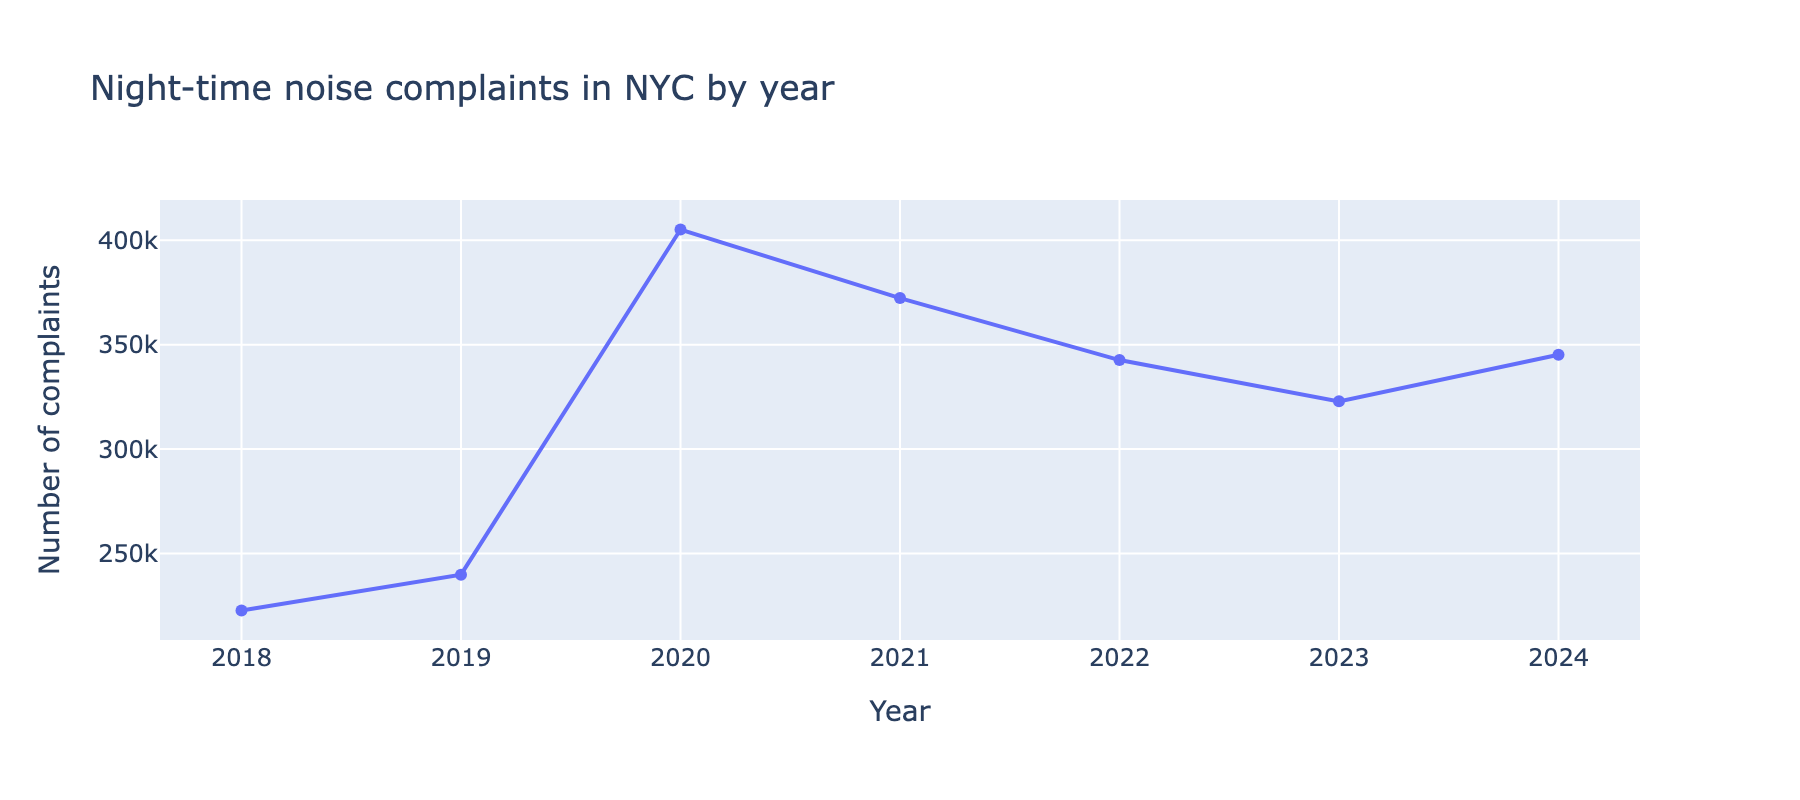

In [12]:
import plotly.express as px

fig = px.line(
    night_by_year,
    x="year",
    y="complaints",
    markers=True,
    title="Night-time noise complaints in NYC by year"
)
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Number of complaints"
)


import plotly.io as pio
from IPython.display import Image, display

pio.write_image(fig, "figure1.png", width=900, height=400, scale=2)

display(Image("figure1.png"))



In [16]:
night_by_year_boro = (
    night_noise
    .groupby(["year", "borough"])
    .size()
    .reset_index(name="complaints")
    .sort_values(["borough", "year"])
)

night_by_year_boro.head()


,year,borough,complaints
0,2018,BRONX,44894
6,2019,BRONX,50601
12,2020,BRONX,128345
18,2021,BRONX,103631
24,2022,BRONX,107252


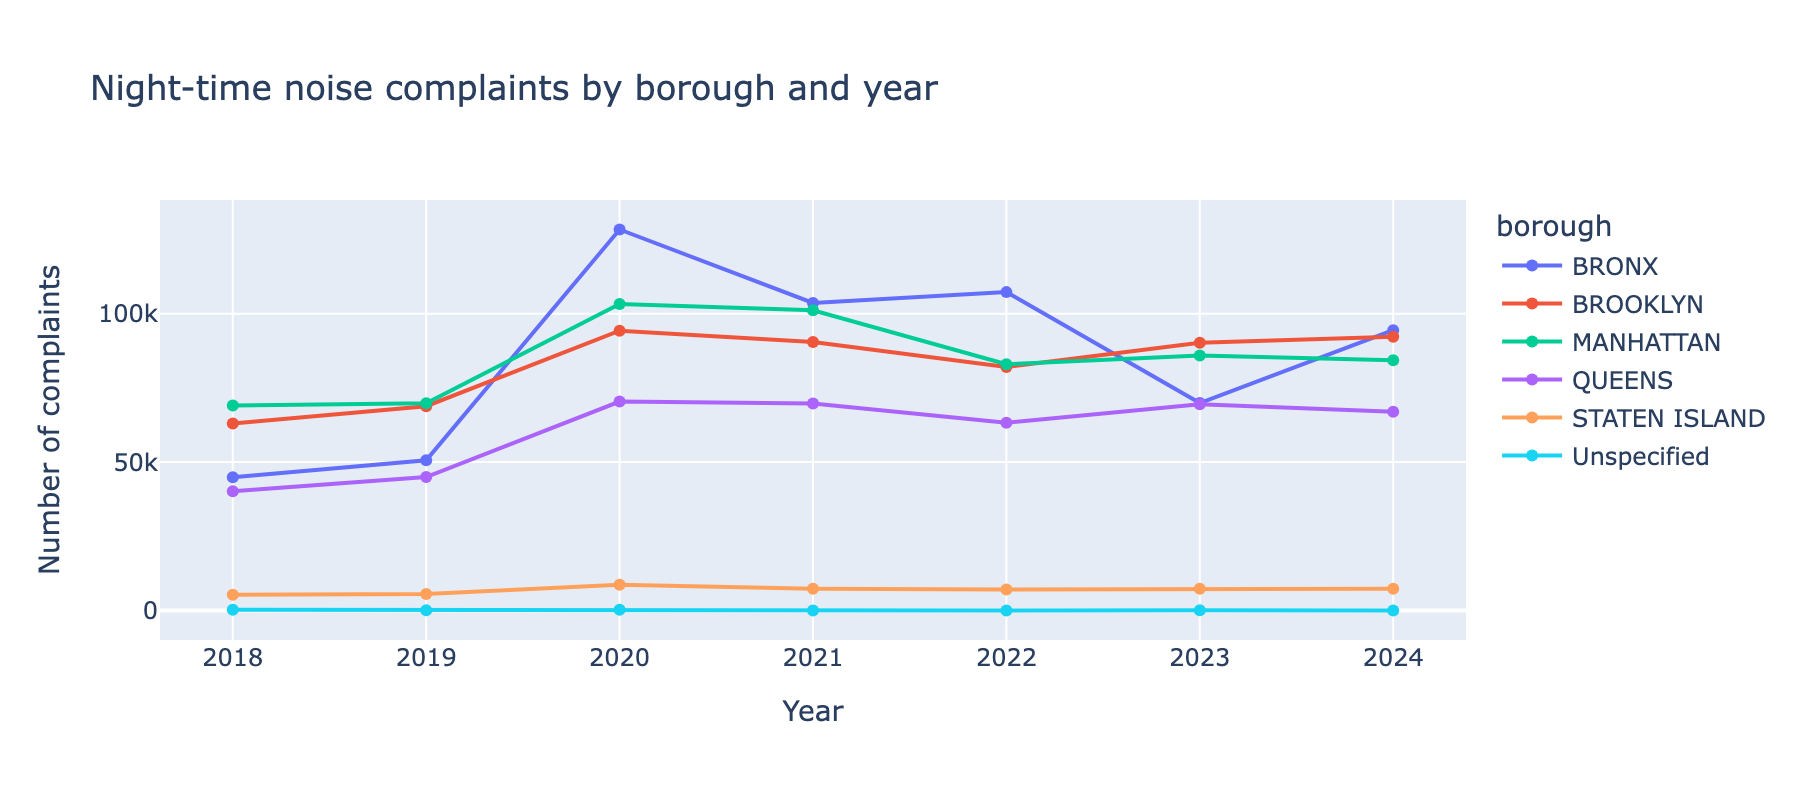

In [18]:
fig = px.line(
    night_by_year_boro,
    x="year",
    y="complaints",
    color="borough",
    markers=True,
    title="Night-time noise complaints by borough and year"
)
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Number of complaints"
)

pio.write_image(fig, "figure2.png", width=900, height=400, scale=2)

display(Image("figure2.png"))


### Annual trend summary

The citywide time series shows that night-time noise complaints **increased sharply around 2020**. Between 2018 and 2019, total complaints rose moderately (from about 223k to 240k), but in **2020 they jumped to more than 400k**. After this peak, complaints **declined gradually** in 2021 and 2022 and then **stabilized at a slightly lower level** in 2023, with a **small uptick in 2024**. This pattern is consistent with the idea that the COVID-19 period intensified conflicts around noise (more people at home, more sensitive to loud neighbors), followed by a partial normalization.

Looking at the borough-level trends, **Bronx, Brooklyn, and Manhattan** account for most of the night-time noise complaints throughout the period. Bronx shows the most dramatic spike in 2020, while Brooklyn and Manhattan also increase sharply and then decline. **Queens** has fewer night-time complaints but follows a similar shape, and **Staten Island** consistently has the lowest counts. Overall, the trends suggest that night-time noise is a persistent issue across the city, with particularly high and volatile complaint volumes in the more densely populated boroughs.


## Step 4 – Borough differences and per-capita complaint rates

In this step I compare night-time noise complaints across NYC boroughs and then adjust for population size to see which boroughs experience the highest burden of night-time noise. This will answer my second question.

### 4.1 Check borough values and exclude unspecified entries

First, I look at the unique values in the `borough` column to see what categories exist.  
I then remove rows where the borough is `"Unspecified"`, since I cannot match those records to a borough population.

In [19]:
night_noise["borough"].value_counts()

borough
BRONX            599053
MANHATTAN        596443
BROOKLYN         580932
QUEENS           424899
STATEN ISLAND     48633
Unspecified         752
Name: count, dtype: int64

In [20]:
night_boro = night_noise[night_noise["borough"] != "Unspecified"].copy()
len(night_boro)

2249986

### 4.2 Compute total night-time noise complaints by borough

Next, I group the data by `borough` and count the number of night-time noise complaints for each borough over the period 2018–2024.


In [21]:
night_by_boro = (
    night_boro
    .groupby("borough")
    .size()
    .reset_index(name="complaints")
    .sort_values("complaints", ascending=False)
)

night_by_boro


,borough,complaints
0,BRONX,599053
2,MANHATTAN,596443
1,BROOKLYN,580932
3,QUEENS,424899
4,STATEN ISLAND,48633


### 4.3 Add borough population and calculate complaints per 10,000 residents

To make the comparison fair, I merge the complaint counts with 2020 Census population estimates for each borough.  
I then compute a per-capita measure: **night-time noise complaints per 10,000 residents**.


In [23]:
borough_pop = pd.DataFrame({
    "borough": ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"],
    "population_2020": [1472654, 2736074, 1694251, 2405464, 495747]
})


night_by_boro["borough"] = night_by_boro["borough"].str.upper()
borough_pop["borough"] = borough_pop["borough"].str.upper()

boro_rates = night_by_boro.merge(borough_pop, on="borough", how="left")

boro_rates["complaints_per_10k"] = (
    boro_rates["complaints"] / boro_rates["population_2020"] * 10000
)

boro_rates


,borough,complaints,population_2020,complaints_per_10k
0,BRONX,599053,1472654,4067.846215
1,MANHATTAN,596443,1694251,3520.393377
2,BROOKLYN,580932,2736074,2123.232047
3,QUEENS,424899,2405464,1766.391016
4,STATEN ISLAND,48633,495747,981.004424


### 4.4 Visualize per-capita complaint rates by borough

Finally, I sort boroughs by their per-capita complaint rates and plot a bar chart.  
This visualization highlights which boroughs experience the most night-time noise complaints relative to their population size.

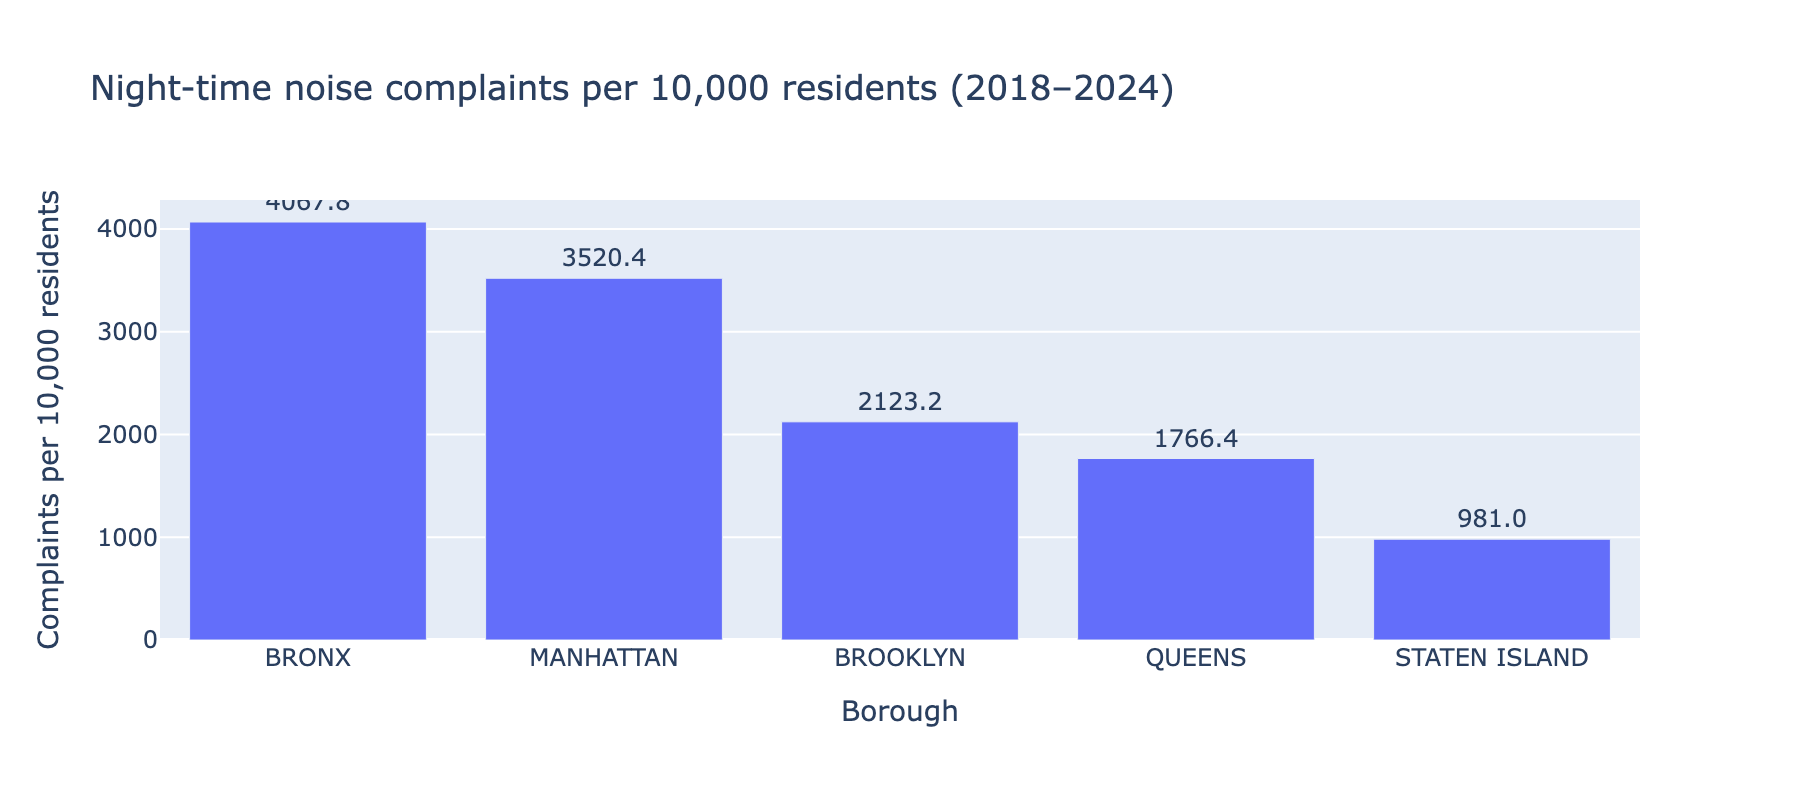

In [26]:
boro_rates_sorted = boro_rates.sort_values("complaints_per_10k", ascending=False)

fig = px.bar(
    boro_rates_sorted,
    x="borough",
    y="complaints_per_10k",
    title="Night-time noise complaints per 10,000 residents (2018–2024)",
    text="complaints_per_10k"
)
fig.update_traces(texttemplate="%{text:.1f}", textposition="outside")
fig.update_layout(
    xaxis_title="Borough",
    yaxis_title="Complaints per 10,000 residents",
    uniformtext_minsize=8,
    uniformtext_mode="hide"
)

pio.write_image(fig, "figure3.png", width=900, height=400, scale=2)

display(Image("figure3.png"))


### Which boroughs are most affected?

Looking across 2018–2024, Bronx, Manhattan and Brooklyn all generate a very large number of night-time noise complaints in absolute terms, while Queens and Staten Island have substantially fewer. After adjusting for population, the ranking becomes even clearer: Bronx has the highest burden with about **4,100 complaints per 10,000 residents**, followed by Manhattan (≈ **3,500 per 10k**). Brooklyn and Queens sit in the middle (around **2,100** and **1,800 complaints per 10k** respectively), and Staten Island has by far the lowest rate (≈ **1,000 per 10k**). This suggests that even after controlling for population size, residents in Bronx and Manhattan experience disproportionately high levels of night-time noise, while Staten Island is relatively quiet.


## Step 5 – When do people complain? Hourly and weekly patterns

In this step I examine **when** night-time noise complaints occur by looking at the distribution across hours of the night and days of the week.
This will answer question 3.

### 5.1 Distribution of night-time noise complaints by hour

First, I look at how night-time noise complaints are distributed across the 24 hours of the day.  
Although `night_noise` already filters to night-time hours, plotting complaints by `hour` shows which hours of the late evening and early morning generate the most complaints.

In [27]:
night_by_hour = (
    night_noise
    .groupby("hour")
    .size()
    .reset_index(name="complaints")
    .sort_values("hour")
)

night_hours_order = [22, 23, 0, 1, 2, 3, 4, 5]
night_by_hour["hour_str"] = night_by_hour["hour"].astype(str)
night_by_hour["hour_str"] = pd.Categorical(
    night_by_hour["hour_str"],
    categories=[str(h) for h in night_hours_order],
    ordered=True
)
night_by_hour = night_by_hour.sort_values("hour_str")
night_by_hour

,hour,complaints,hour_str
6,22,514036,22
7,23,521569,23
0,0,437804,0
1,1,303798,1
2,2,191937,2
3,3,127841,3
4,4,90437,4
5,5,63316,5


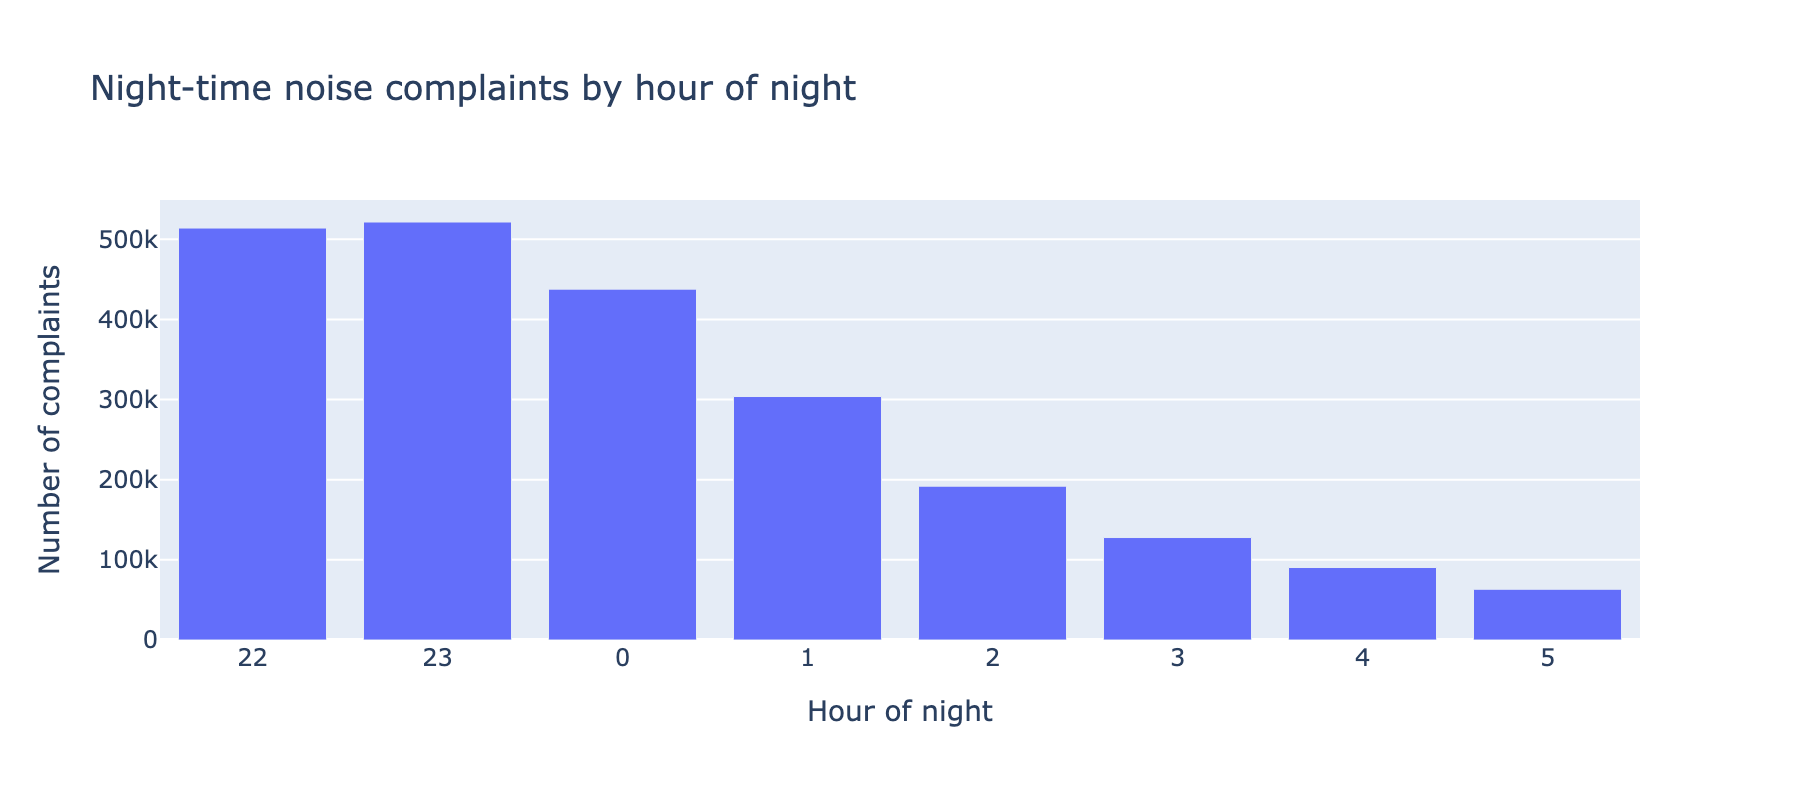

In [29]:
fig = px.bar(
    night_by_hour,
    x="hour_str",
    y="complaints",
    title="Night-time noise complaints by hour of night"
)
fig.update_layout(
    xaxis_title="Hour of night",
    yaxis_title="Number of complaints"
)

pio.write_image(fig, "figure4.png", width=900, height=400, scale=2)

display(Image("figure4.png"))


### 5.2 Weekly pattern: complaints by weekday and hour

Next, I explore how night-time noise complaints vary across the week.  
I group the data by both `weekday` and `hour` and create a 7×24 table of complaint counts, which I visualize as a heatmap.  

This shows whether complaints are concentrated on certain nights (for example, Friday and Saturday) and at particular hours (such as around midnight or 2am).

In [30]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

night_noise["weekday"] = pd.Categorical(
    night_noise["weekday"],
    categories=weekday_order,
    ordered=True
)

heat = (
    night_noise
    .groupby(["weekday", "hour"], observed=True)
    .size()
    .reset_index(name="complaints")
)

heat.head()

,weekday,hour,complaints
0,Monday,0,57744
1,Monday,1,36361
2,Monday,2,22031
3,Monday,3,14934
4,Monday,4,11047


In [31]:
heat_pivot = (
    heat
    .pivot(index="weekday", columns="hour", values="complaints")
    .fillna(0)
)

heat_pivot

hour,0,1,2,3,4,5,22,23
weekday,,,,,,,,
Monday,57744,36361,22031,14934,11047,8706,54206,49047
Tuesday,36779,23866,15350,10588,8421,6557,53772,49416
Wednesday,36963,23565,15012,10085,7621,6270,53686,50112
Thursday,37256,23515,14833,9674,7574,6144,59765,58039
Friday,45247,28851,17634,11883,8683,6653,83618,96169
Saturday,88188,63247,40479,27063,18672,11771,124164,142623
Sunday,135627,104393,66598,43614,28419,17215,84825,76163


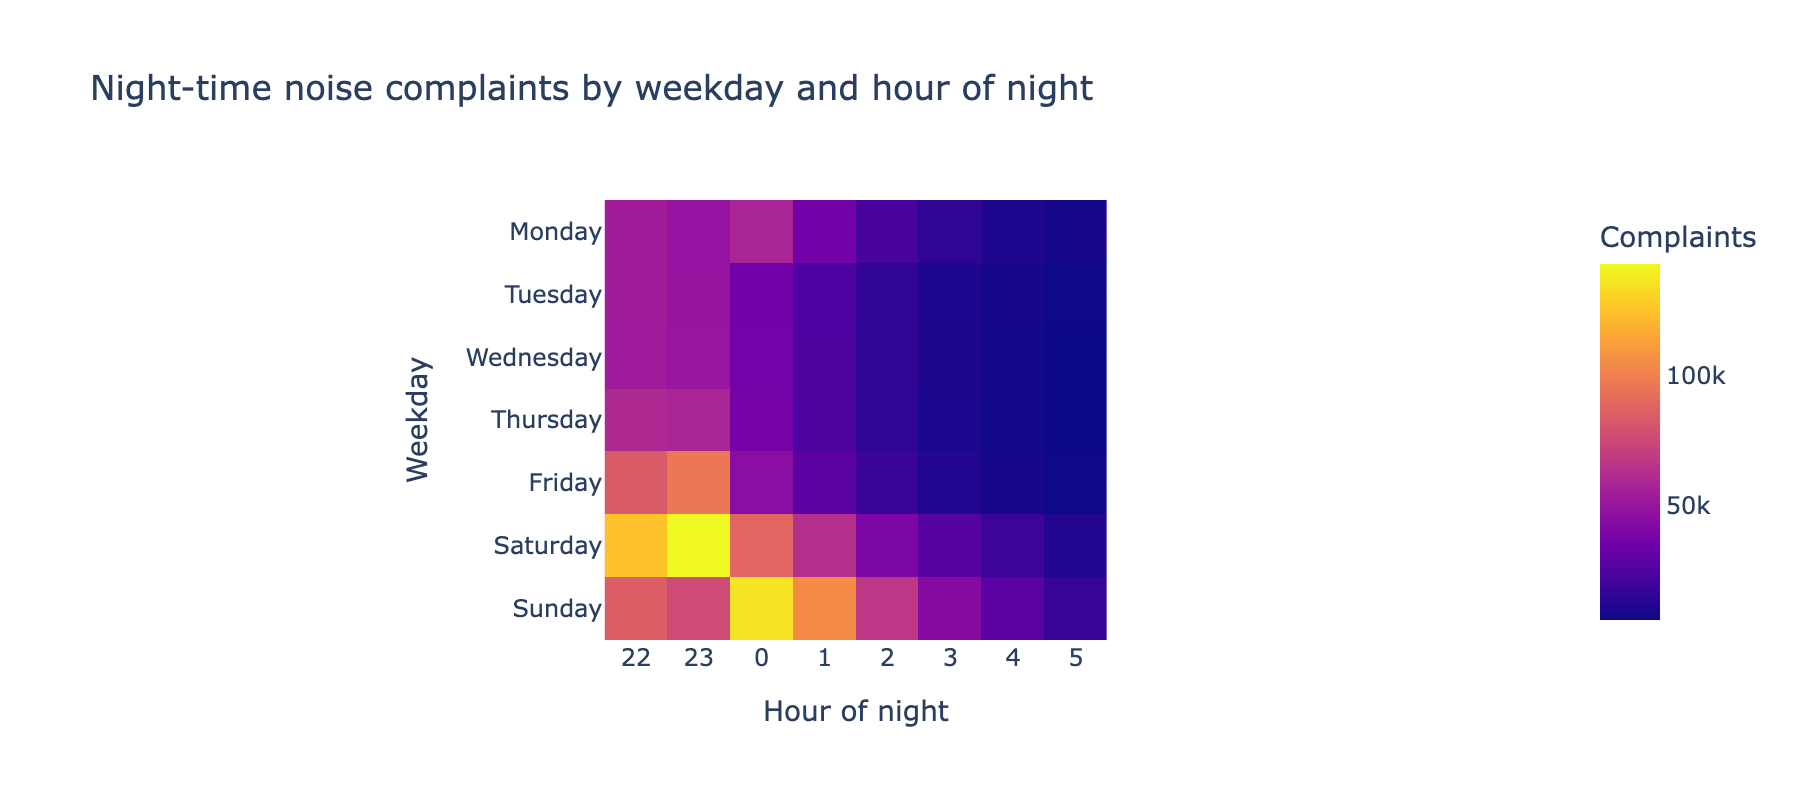

In [33]:

night_hours_order = [22, 23, 0, 1, 2, 3, 4, 5]

heat_pivot_night = heat_pivot[night_hours_order].copy()

heat_pivot_night.columns = [str(h) for h in heat_pivot_night.columns]

fig = px.imshow(
    heat_pivot_night,
    labels=dict(x="Hour of night", y="Weekday", color="Complaints"),
    title="Night-time noise complaints by weekday and hour of night"
)
fig.update_xaxes(dtick=1)

pio.write_image(fig, "figure5.png", width=900, height=400, scale=2)

display(Image("figure5.png"))



### When do people complain?

The bar chart indicates that complaints peak around **10–11pm (22–23h)** and remain very high at **midnight (0h)**. After that, the volume drops steadily through the early morning hours, reaching its lowest level around **5am**. This pattern suggests that most night-time noise conflicts happen in the late evening and early night, rather than in the very early morning.

The heatmap adds the **day-of-week dimension**. It shows that late-night complaints are present on all days, but they are much more concentrated on **Friday and Saturday nights**, and in the **early hours of Saturday and Sunday (0–2am)**. In other words, weekend nightlife drives a disproportionate share of night-time noise complaints, while weekday nights are comparatively quieter.


## Step 6 – Where are the hotspots? ZIP code choropleth map

Here I look at the **spatial distribution** of night-time noise complaints across New York City ZIP codes by creating a choropleth map.

### 6.1 Prepare ZIP codes and aggregate complaints

First, I clean the `incident_zip` column:

- convert it to a 5-digit string,  
- drop missing ZIP codes,  

and then count the number of night-time noise complaints in each ZIP code.


In [34]:
night_noise["incident_zip"] = (
    night_noise["incident_zip"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)  
    .str.zfill(5)
)


night_zip = night_noise.dropna(subset=["incident_zip"]).copy()

night_by_zip = (
    night_zip
    .groupby("incident_zip")
    .size()
    .reset_index(name="complaints")
)

night_by_zip.head()


,incident_zip,complaints
0,00000,1
1,00083,1
2,10000,94
3,10001,10822
4,10002,33156


### 6.2 Load the ZIP code GeoJSON

Next, I load a GeoJSON file containing NYC ZIP code boundaries.  
I inspect the properties of one feature to identify which field stores the ZIP code (e.g. `postalCode`, `ZCTA5CE10`, or `ZIPCODE`).


In [35]:
import json

with open("nyc_zip_codes.geojson", "r") as f:
    zip_geojson = json.load(f)


zip_geojson["features"][0]["properties"]


{'MODZCTA': '10001', 'label': '10001, 10118'}

### 6.3 Plot a choropleth map of night-time noise complaints by ZIP code

Finally, I join the ZIP-level complaint counts with the GeoJSON boundaries and draw a choropleth map.  
Darker areas on the map represent ZIP codes with more night-time noise complaints, highlighting spatial hotspots.

In [36]:
night_zip = night_noise.dropna(subset=["incident_zip"]).copy()


night_zip["zip_str"] = (
    night_zip["incident_zip"]
    .astype(int)         
    .astype(str)          
    .str.zfill(5)         
)


night_by_zip = (
    night_zip
    .groupby("zip_str")
    .size()
    .reset_index(name="complaints")
)

night_by_zip.head()


,zip_str,complaints
0,00000,1
1,00083,1
2,10000,94
3,10001,10822
4,10002,33156


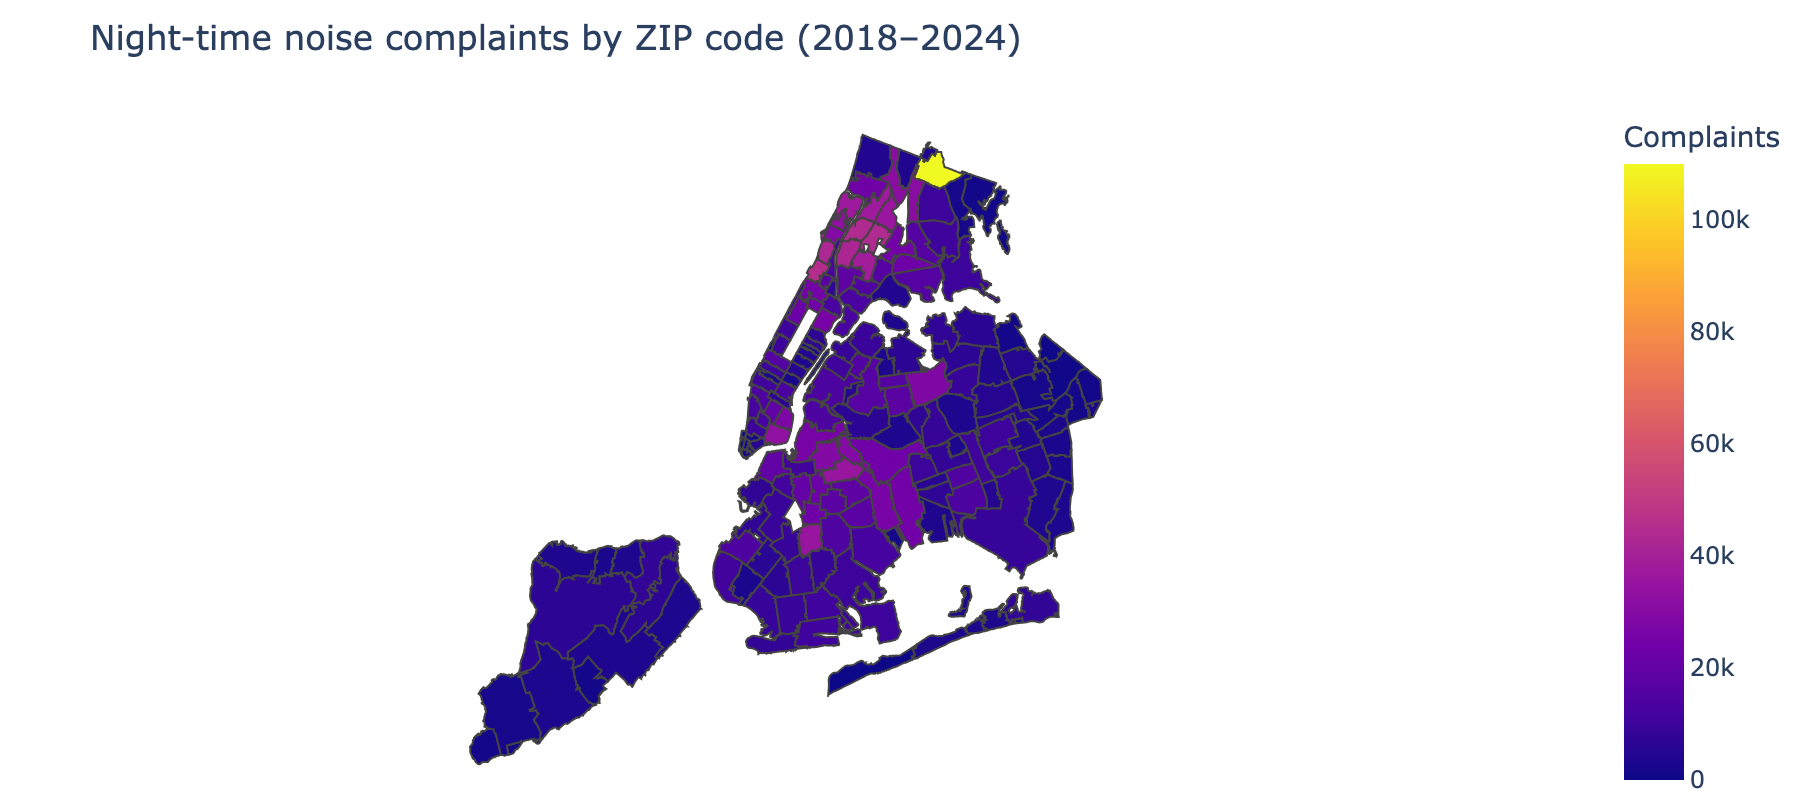

In [38]:
fig = px.choropleth(
    night_by_zip,
    geojson=zip_geojson,
    locations="zip_str",         
    color="complaints",
    featureidkey="properties.MODZCTA", 
    projection="mercator",
    title="Night-time noise complaints by ZIP code (2018–2024)",
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    margin={"r":0, "t":50, "l":0, "b":0},
    coloraxis_colorbar_title="Complaints"
)

pio.write_image(fig, "figure6.png", width=900, height=400, scale=2)

display(Image("figure6.png"))


### Where are night-time noise complaints concentrated?

This choropleth map shows the total number of night-time noise complaints by ZIP code across New York City from 2018–2024. Darker (yellow) areas represent ZIP codes with more complaints, while lighter (purple) areas have fewer.

The map reveals clear spatial clustering. A small number of ZIP codes in northern parts of the city stand out as major hot spots, with much higher complaint volumes than surrounding areas. In contrast, many ZIP codes in Staten Island and the outer edges of Queens and Brooklyn report relatively few night-time complaints. Overall, night-time noise problems are concentrated in a limited set of dense, urban neighborhoods rather than being evenly distributed across the city.


## Conclusion

This project set out to use NYC’s 311 data to understand **how, where, and when** residents complain about night-time noise, and to test several hypotheses about trends and disparities across the city.

Looking at trends over time, I find that night-time noise complaints increased from 2018 to a sharp peak around 2020, followed by a gradual decline but remaining above pre-2018 levels. This pattern partly supports my first hypothesis that complaints would rise over time, but the data also suggest a more complex story: the spike around 2020 likely reflects pandemic-related changes in how often people stayed at home and how sensitive they were to neighborhood noise, rather than a smooth, linear increase in noise itself.

The borough comparison shows large and persistent differences. In raw counts, Bronx, Brooklyn, and Manhattan consistently generate many more night-time complaints than Queens and Staten Island. After adjusting for population, the Bronx emerges as the borough with the **highest per-capita rate**, with Manhattan and Brooklyn also relatively high and Queens and Staten Island substantially lower. This **partly confirms** my second hypothesis: Manhattan and Brooklyn are indeed noisy on a per-resident basis, but the results also highlight that the Bronx experiences an even greater burden of night-time noise complaints than I initially expected.

The temporal patterns within each day and week align closely with my expectations. Night-time complaints are heavily concentrated in the late evening and early morning hours, especially around the typical “going-out” window (roughly 10pm–2am), and the weekday–hour heatmap reveals clear peaks on **Friday and Saturday nights**. This strongly supports my hypothesis that weekend late nights are when residents are most likely to pick up the phone and call 311 about noise.

Spatially, the ZIP-code map reveals distinct hotspots clustered in dense, mixed-use areas with active nightlife, compared with quieter, more residential or peripheral neighborhoods. Combined with the breakdown of complaint types—where **“Loud Music/Party”** dominates and construction and vehicle noise play secondary roles—this supports my final hypothesis that neighborhoods with many bars and clubs would stand out as night-time noise hotspots. The results suggest that night-time noise in NYC is not evenly distributed: it is concentrated in particular boroughs, neighborhoods, times of day, and types of activity.

Overall, the analysis shows that night-time noise complaints are shaped by a combination of **time**, **place**, and **activity**. While the data confirm some popular perceptions—weekend midnight parties in dense nightlife areas—they also highlight less visible patterns, such as the especially high per-capita burden in the Bronx. Because 311 data capture complaints rather than objective sound levels, and because reporting behavior may differ across communities, these findings should be interpreted cautiously. Even so, they offer a useful starting point for policymakers who want to target enforcement or noise-mitigation efforts toward the places and times where residents experience night-time noise most intensely.
